In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("✓ Libraries loaded successfully!")

✓ Libraries loaded successfully!


In [2]:
unemployment_df = pd.read_csv("C:\\Users\\Lenovo\\Downloads\\Unemployment in India.csv")  

print("Dataset loaded successfully!")
print(f"Dataset Shape: {unemployment_df.shape}")
print("\nFirst 10 rows:")
print(unemployment_df.head(10))
print("\nColumn Names:")
print(unemployment_df.columns.tolist())
print("\nData Types:")
print(unemployment_df.dtypes)

Dataset loaded successfully!
Dataset Shape: (768, 7)

First 10 rows:
           Region         Date  Frequency   Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019    Monthly                              3.65   
1  Andhra Pradesh   30-06-2019    Monthly                              3.05   
2  Andhra Pradesh   31-07-2019    Monthly                              3.75   
3  Andhra Pradesh   31-08-2019    Monthly                              3.32   
4  Andhra Pradesh   30-09-2019    Monthly                              5.17   
5  Andhra Pradesh   31-10-2019    Monthly                              3.52   
6  Andhra Pradesh   30-11-2019    Monthly                              4.12   
7  Andhra Pradesh   31-12-2019    Monthly                              4.38   
8  Andhra Pradesh   31-01-2020    Monthly                              4.84   
9  Andhra Pradesh   29-02-2020    Monthly                              5.91   

    Estimated Employed   Estimated Labour Participation Rate 

In [3]:
print("="*70)
print("DATASET INFORMATION")
print("="*70)
print(unemployment_df.info())

print("\n" + "="*70)
print("STATISTICAL SUMMARY")
print("="*70)
print(unemployment_df.describe())

print("\n" + "="*70)
print("MISSING VALUES")
print("="*70)
print(unemployment_df.isnull().sum())

print("\n" + "="*70)
print("UNIQUE VALUES PER COLUMN")
print("="*70)
for col in unemployment_df.columns:
    unique_count = unemployment_df[col].nunique()
    print(f"{col}: {unique_count} unique values")

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB
None

STATISTICAL SUMMARY
       Estimated Unemployment Rate (%)  Estimated Employed  \
count                       740.000000        7.400000e+02   
mean                         11.78

In [4]:
date_column = None
for col in unemployment_df.columns:
    if unemployment_df[col].dtype == 'object':
        try:
            pd.to_datetime(unemployment_df[col].head())
            date_column = col
            print(f"✓ Date column detected: {col}")
            break
        except:
            pass
    
if date_column is None:
    print("⚠ Could not auto-detect date column. Please specify manually above.")
else:
    unemployment_df[date_column] = pd.to_datetime(unemployment_df[date_column])
    unemployment_df = unemployment_df.sort_values(date_column).reset_index(drop=True)
    unemployment_df['Year'] = unemployment_df[date_column].dt.year
    unemployment_df['Month'] = unemployment_df[date_column].dt.month
    unemployment_df['Quarter'] = unemployment_df[date_column].dt.quarter
    unemployment_df['Month_Name'] = unemployment_df[date_column].dt.strftime('%B')
    
    print(f"\n✓ Date column '{date_column}' parsed successfully!")
    print(f"Date range: {unemployment_df[date_column].min()} to {unemployment_df[date_column].max()}")

✓ Date column detected:  Date

✓ Date column ' Date' parsed successfully!
Date range: 2019-05-31 00:00:00 to 2020-06-30 00:00:00


In [5]:
rate_column = None
for col in unemployment_df.columns:
    col_lower = col.lower()
    if ('unemployment' in col_lower or 'rate' in col_lower) and unemployment_df[col].dtype in ['float64', 'int64']:
        rate_column = col
        print(f"✓ Unemployment rate column detected: {col}")
        break
if rate_column is None:
    print("⚠ Could not detect unemployment rate column. Showing all numeric columns:")
    print(unemployment_df.select_dtypes(include=[np.number]).columns.tolist())
    print("Please specify the rate_column manually above.")
else:
    print(f"\nUnemployment Rate Statistics:")
    print(unemployment_df[rate_column].describe())

✓ Unemployment rate column detected:  Estimated Unemployment Rate (%)

Unemployment Rate Statistics:
count    740.000000
mean      11.787946
std       10.721298
min        0.000000
25%        4.657500
50%        8.350000
75%       15.887500
max       76.740000
Name:  Estimated Unemployment Rate (%), dtype: float64


In [6]:
if unemployment_df[rate_column].isnull().sum() > 0:
    print(f"Removing {unemployment_df[rate_column].isnull().sum()} rows with missing unemployment rate...")
    unemployment_df = unemployment_df.dropna(subset=[rate_column])
if unemployment_df.isnull().sum().sum() > 0:
    print("\nHandling remaining missing values...")
    unemployment_df = unemployment_df.fillna(method='ffill')
duplicates = unemployment_df.duplicated(subset=[date_column]).sum()
if duplicates > 0:
    print(f"Removing {duplicates} duplicate dates...")
    unemployment_df = unemployment_df.drop_duplicates(subset=[date_column])

print(f"\n✓ Clean dataset shape: {unemployment_df.shape}")

Removing 28 rows with missing unemployment rate...
Removing 726 duplicate dates...

✓ Clean dataset shape: (14, 11)


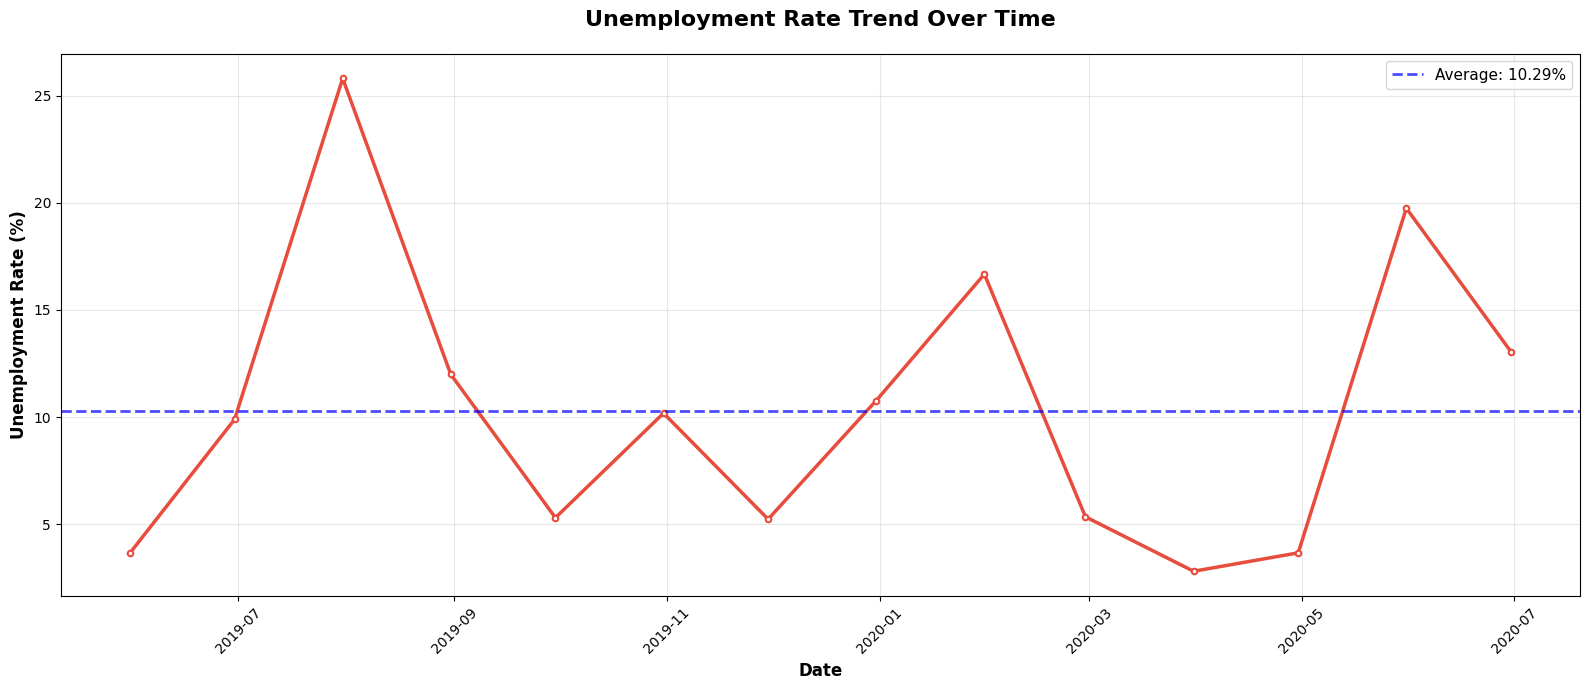

In [7]:
fig, ax = plt.subplots(figsize=(16, 7))
ax.plot(unemployment_df[date_column], unemployment_df[rate_column], 
        linewidth=2.5, color='#e74c3c', marker='o', markersize=4, 
        markerfacecolor='white', markeredgewidth=1.5)
mean_rate = unemployment_df[rate_column].mean()
ax.axhline(y=mean_rate, color='blue', linestyle='--', linewidth=2, 
           label=f'Average: {mean_rate:.2f}%', alpha=0.7)
if unemployment_df['Year'].max() >= 2020 and unemployment_df['Year'].min() <= 2020:
    try:
        covid_start = pd.to_datetime('2020-03-01')
        covid_end = unemployment_df[unemployment_df['Year'] == 2021][date_column].max()
        
        ax.axvspan(covid_start, covid_end, alpha=0.2, color='red', 
                   label='COVID-19 Period')
    except:
        pass

ax.set_title('Unemployment Rate Trend Over Time', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Unemployment Rate (%)', fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

YEARLY UNEMPLOYMENT STATISTICS
        Average  Minimum  Maximum  Std Dev
Year                                      
2019.0    10.35     3.65    25.81     6.96
2020.0    10.21     2.80    19.75     7.24


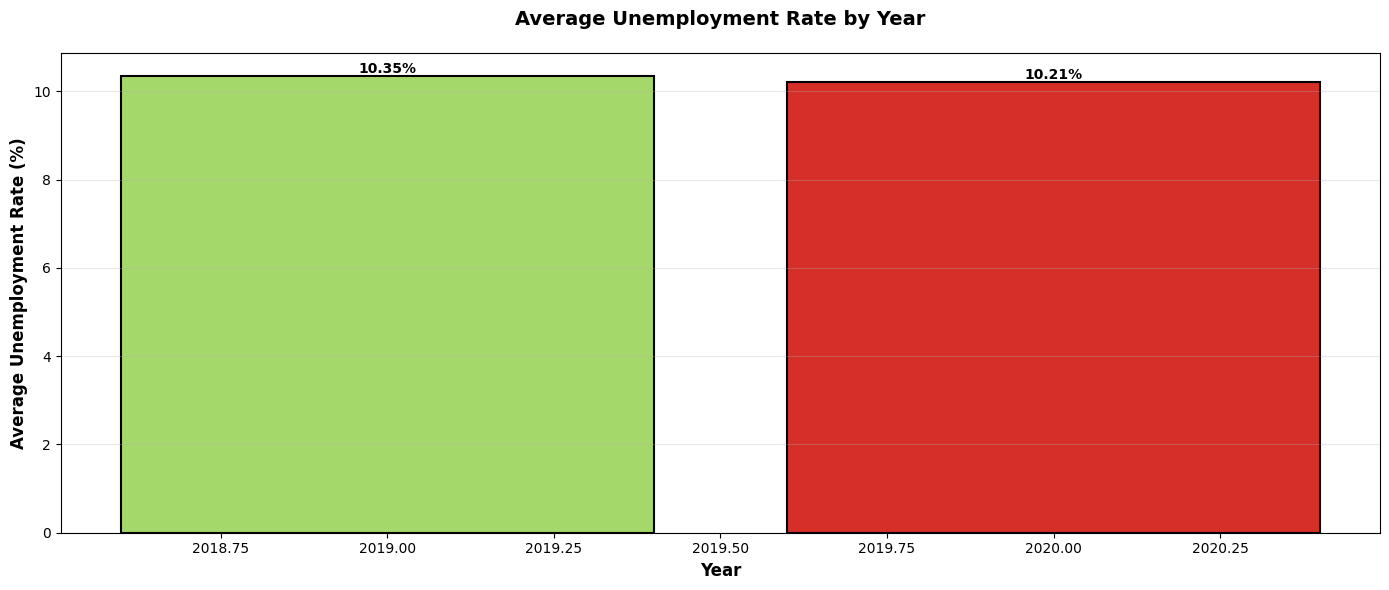


✓ Lowest Average Unemployment: 2020.0 (10.21%)
✗ Highest Average Unemployment: 2019.0 (10.35%)


In [10]:
yearly_stats = unemployment_df.groupby('Year')[rate_column].agg([
    ('Average', 'mean'),
    ('Minimum', 'min'),
    ('Maximum', 'max'),
    ('Std Dev', 'std')
]).round(2)

print("="*70)
print("YEARLY UNEMPLOYMENT STATISTICS")
print("="*70)
print(yearly_stats)
fig, ax = plt.subplots(figsize=(14, 6))
yearly_avg = unemployment_df.groupby('Year')[rate_column].mean()

colors = plt.cm.RdYlGn_r(np.linspace(0.3, 0.9, len(yearly_avg)))
bars = ax.bar(yearly_avg.index, yearly_avg.values, color=colors, 
              edgecolor='black', linewidth=1.5)
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Average Unemployment Rate by Year', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Unemployment Rate (%)', fontsize=12, fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()
best_year = yearly_avg.idxmin()
worst_year = yearly_avg.idxmax()
print(f"\n✓ Lowest Average Unemployment: {best_year} ({yearly_avg[best_year]:.2f}%)")
print(f"✗ Highest Average Unemployment: {worst_year} ({yearly_avg[worst_year]:.2f}%)")

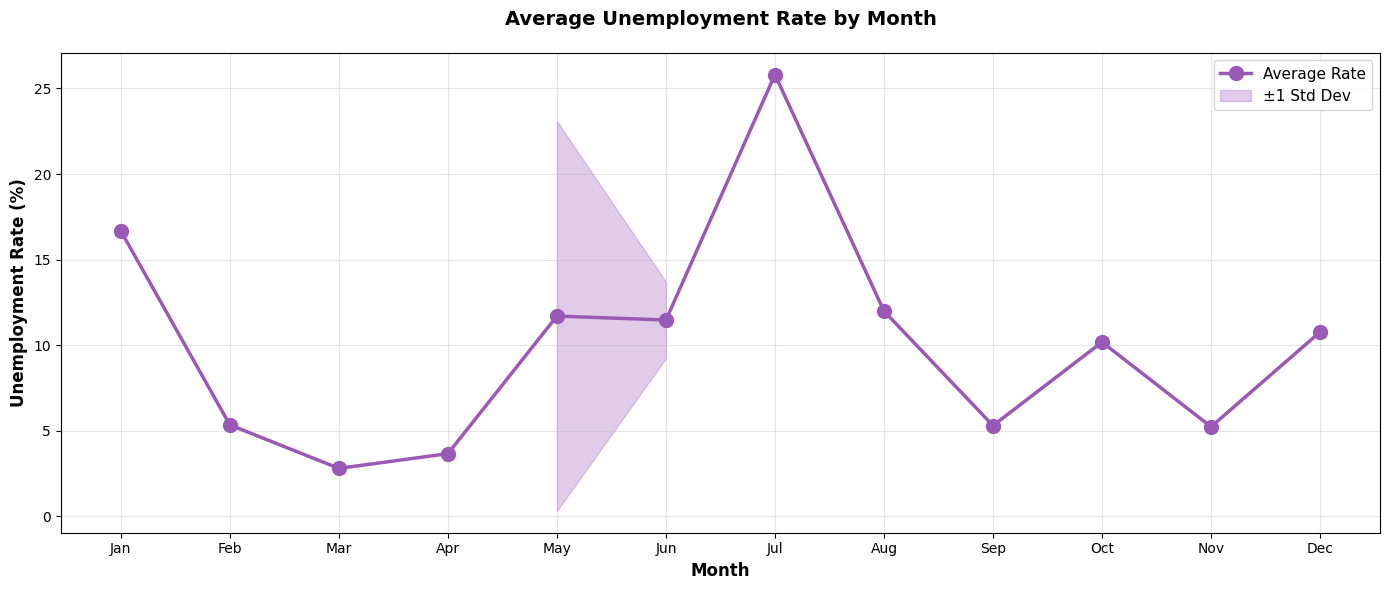


Monthly Average Unemployment Rate:
  Jan: 16.67%
  Feb: 5.34%
  Mar: 2.80%
  Apr: 3.66%
  May: 11.70%
  Jun: 11.47%
  Jul: 25.81%
  Aug: 11.99%
  Sep: 5.30%
  Oct: 10.18%
  Nov: 5.23%
  Dec: 10.77%


In [11]:
monthly_avg = unemployment_df.groupby('Month')[rate_column].mean().sort_index()
monthly_std = unemployment_df.groupby('Month')[rate_column].std().sort_index()

fig, ax = plt.subplots(figsize=(14, 6))
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

ax.plot(range(1, 13), monthly_avg.values, marker='o', markersize=10, 
        linewidth=2.5, color='#9b59b6', label='Average Rate')

ax.fill_between(range(1, 13), 
                monthly_avg.values - monthly_std.values,
                monthly_avg.values + monthly_std.values,
                alpha=0.3, color='#9b59b6', label='±1 Std Dev')

ax.set_xticks(range(1, 13))
ax.set_xticklabels(months)
ax.set_title('Average Unemployment Rate by Month', fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Month', fontsize=12, fontweight='bold')
ax.set_ylabel('Unemployment Rate (%)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("\nMonthly Average Unemployment Rate:")
for month, rate in zip(months, monthly_avg.values):
    print(f"  {month}: {rate:.2f}%")


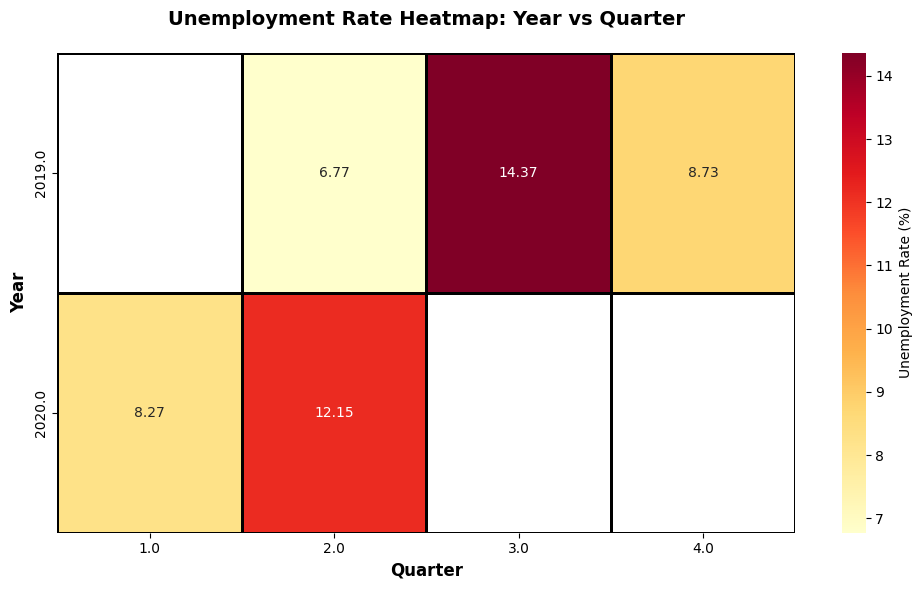

In [12]:

quarterly_avg = unemployment_df.groupby(['Year', 'Quarter'])[rate_column].mean().round(2)


pivot_quarterly = unemployment_df.pivot_table(
    values=rate_column,
    index='Year',
    columns='Quarter',
    aggfunc='mean'
)


plt.figure(figsize=(10, max(6, len(pivot_quarterly)//2)))
sns.heatmap(pivot_quarterly, annot=True, fmt='.2f', cmap='YlOrRd', 
            cbar_kws={'label': 'Unemployment Rate (%)'}, linewidths=1,
            linecolor='black')
plt.title('Unemployment Rate Heatmap: Year vs Quarter', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Quarter', fontsize=12, fontweight='bold')
plt.ylabel('Year', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

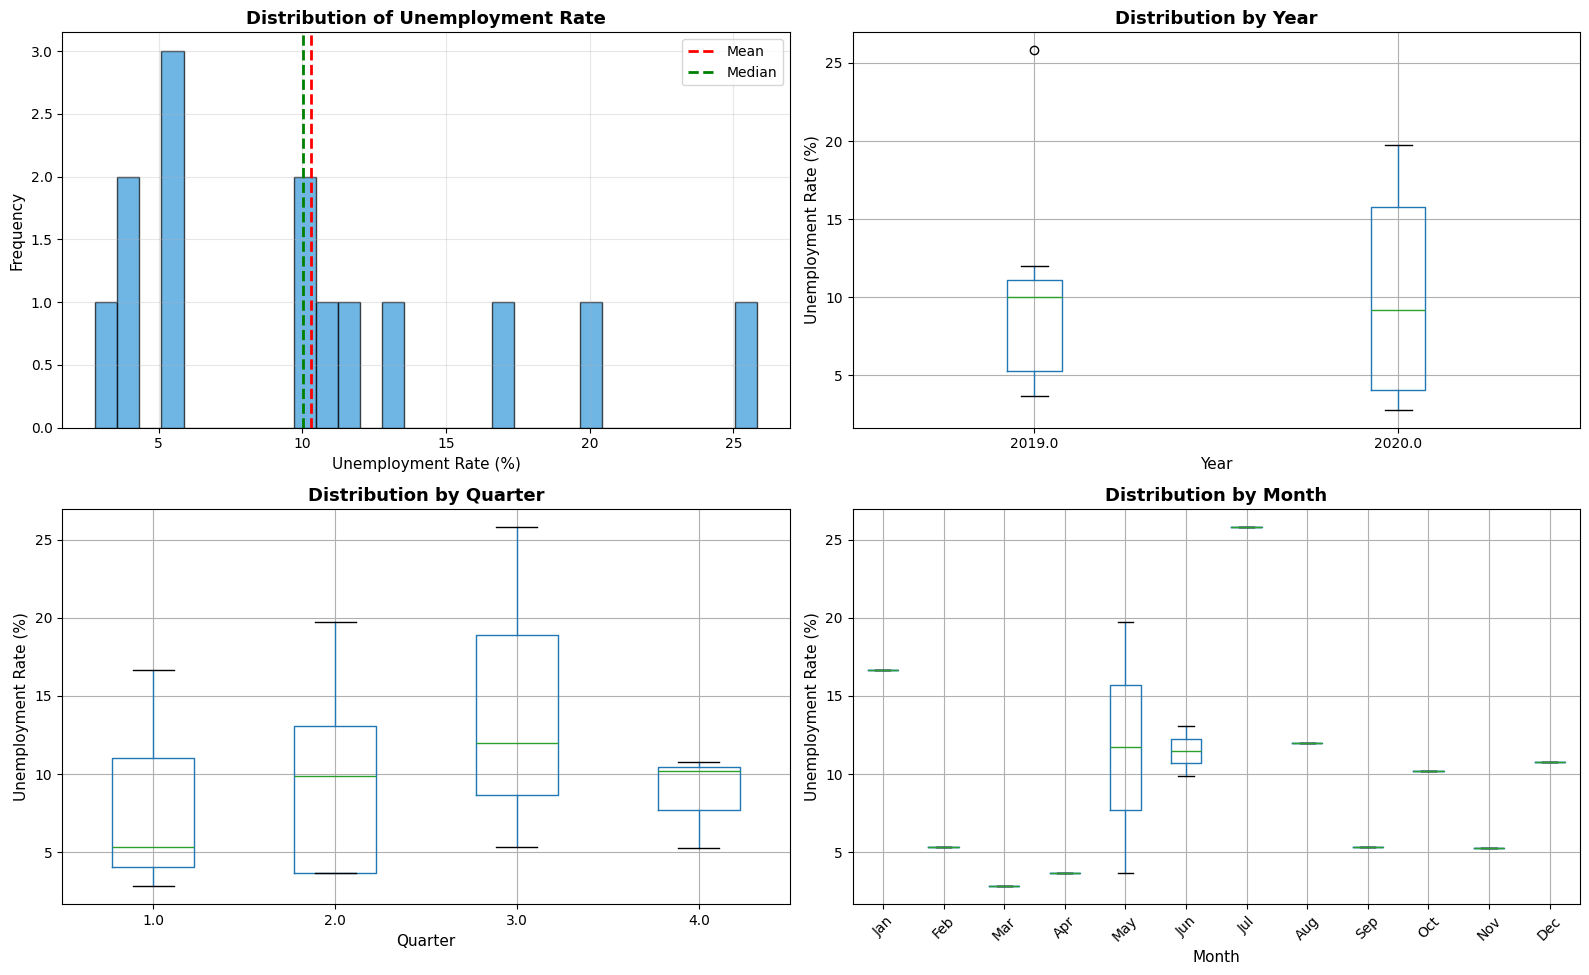

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].hist(unemployment_df[rate_column], bins=30, color='#3498db', 
                edgecolor='black', alpha=0.7)
axes[0, 0].axvline(unemployment_df[rate_column].mean(), color='red', 
                   linestyle='--', linewidth=2, label='Mean')
axes[0, 0].axvline(unemployment_df[rate_column].median(), color='green', 
                   linestyle='--', linewidth=2, label='Median')
axes[0, 0].set_title('Distribution of Unemployment Rate', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('Unemployment Rate (%)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

unemployment_df.boxplot(column=rate_column, by='Year', ax=axes[0, 1])
axes[0, 1].set_title('Distribution by Year', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('Year', fontsize=11)
axes[0, 1].set_ylabel('Unemployment Rate (%)', fontsize=11)
plt.suptitle('')

unemployment_df.boxplot(column=rate_column, by='Quarter', ax=axes[1, 0])
axes[1, 0].set_title('Distribution by Quarter', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('Quarter', fontsize=11)
axes[1, 0].set_ylabel('Unemployment Rate (%)', fontsize=11)
plt.suptitle('')

unemployment_df.boxplot(column=rate_column, by='Month', ax=axes[1, 1])
axes[1, 1].set_title('Distribution by Month', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('Month', fontsize=11)
axes[1, 1].set_ylabel('Unemployment Rate (%)', fontsize=11)
axes[1, 1].set_xticklabels(months, rotation=45)
plt.suptitle('')

plt.tight_layout()
plt.show()

In [14]:
n_periods = 5  

print("="*70)
print(f"TOP {n_periods} PERIODS WITH HIGHEST UNEMPLOYMENT")
print("="*70)
highest = unemployment_df.nlargest(n_periods, rate_column)[[date_column, rate_column]]
for idx, row in highest.iterrows():
    print(f"{row[date_column].strftime('%B %Y')}: {row[rate_column]:.2f}%")

print("\n" + "="*70)
print(f"TOP {n_periods} PERIODS WITH LOWEST UNEMPLOYMENT")
print("="*70)
lowest = unemployment_df.nsmallest(n_periods, rate_column)[[date_column, rate_column]]
for idx, row in lowest.iterrows():
    print(f"{row[date_column].strftime('%B %Y')}: {row[rate_column]:.2f}%")

TOP 5 PERIODS WITH HIGHEST UNEMPLOYMENT
July 2019: 25.81%
May 2020: 19.75%
January 2020: 16.67%
June 2020: 13.05%
August 2019: 11.99%

TOP 5 PERIODS WITH LOWEST UNEMPLOYMENT
March 2020: 2.80%
May 2019: 3.65%
April 2020: 3.66%
November 2019: 5.23%
September 2019: 5.30%


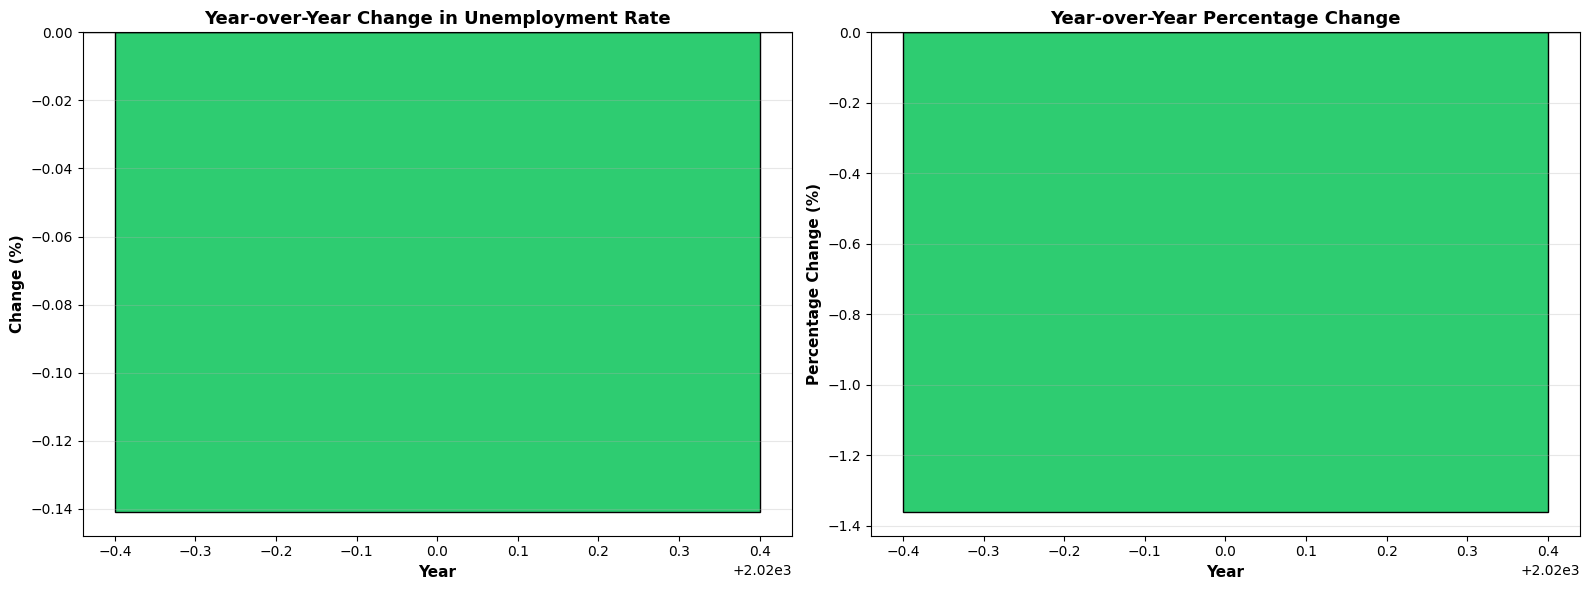


Year-over-Year Changes:
2020.0: ↓ Decrease of 0.14%


In [15]:
yearly_avg = unemployment_df.groupby('Year')[rate_column].mean()
yoy_change = yearly_avg.diff()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))


colors = ['#2ecc71' if x < 0 else '#e74c3c' for x in yoy_change.values]
axes[0].bar(yoy_change.index, yoy_change.values, color=colors, edgecolor='black')
axes[0].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[0].set_title('Year-over-Year Change in Unemployment Rate', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Year', fontsize=11, fontweight='bold')
axes[0].set_ylabel('Change (%)', fontsize=11, fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')

yoy_pct_change = yearly_avg.pct_change() * 100
colors = ['#2ecc71' if x < 0 else '#e74c3c' for x in yoy_pct_change.values]
axes[1].bar(yoy_pct_change.index, yoy_pct_change.values, color=colors, edgecolor='black')
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1)
axes[1].set_title('Year-over-Year Percentage Change', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Year', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Percentage Change (%)', fontsize=11, fontweight='bold')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nYear-over-Year Changes:")
for year, change in yoy_change.items():
    if not np.isnan(change):
        direction = "↓ Decrease" if change < 0 else "↑ Increase"
        print(f"{year}: {direction} of {abs(change):.2f}%")

In [20]:
print("\n" + "="*70)
print("KEY INSIGHTS FROM UNEMPLOYMENT ANALYSIS")
print("="*70)

print(f"\n1. OVERALL STATISTICS:")
print(f"   - Time Period: {unemployment_df[date_column].min().strftime('%B %Y')} to {unemployment_df[date_column].max().strftime('%B %Y')}")
print(f"   - Average Unemployment Rate: {unemployment_df[rate_column].mean():.2f}%")
print(f"   - Median Unemployment Rate: {unemployment_df[rate_column].median():.2f}%")
print(f"   - Standard Deviation: {unemployment_df[rate_column].std():.2f}%")
print(f"   - Highest Rate: {unemployment_df[rate_column].max():.2f}%")
print(f"   - Lowest Rate: {unemployment_df[rate_column].min():.2f}%")

recent_avg = unemployment_df.tail(12)[rate_column].mean()
earlier_avg = unemployment_df.head(12)[rate_column].mean()
trend = "improving (decreasing)" if recent_avg < earlier_avg else "worsening (increasing)"

print(f"\n2. TREND ANALYSIS:")
print(f"   - First year average: {earlier_avg:.2f}%")
print(f"   - Most recent year average: {recent_avg:.2f}%")
print(f"   - Overall trend: {trend}")

print(f"\n3. VOLATILITY:")
print(f"   - Coefficient of Variation: {(unemployment_df[rate_column].std() / unemployment_df[rate_column].mean() * 100):.2f}%")
print(f"   - Range: {unemployment_df[rate_column].max() - unemployment_df[rate_column].min():.2f}%")

highest_month = monthly_avg.idxmax()
lowest_month = monthly_avg.idxmin()
print(f"\n4. SEASONAL PATTERNS:")
print(f"   - Typically highest in: {months[int(highest_month)-1]} ({monthly_avg[highest_month]:.2f}%)")
print(f"   - Typically lowest in: {months[int(lowest_month)-1]} ({monthly_avg[lowest_month]:.2f}%)")


KEY INSIGHTS FROM UNEMPLOYMENT ANALYSIS

1. OVERALL STATISTICS:
   - Time Period: May 2019 to June 2020
   - Average Unemployment Rate: 10.29%
   - Median Unemployment Rate: 10.04%
   - Standard Deviation: 6.80%
   - Highest Rate: 25.81%
   - Lowest Rate: 2.80%

2. TREND ANALYSIS:
   - First year average: 9.27%
   - Most recent year average: 10.88%
   - Overall trend: worsening (increasing)

3. VOLATILITY:
   - Coefficient of Variation: 66.07%
   - Range: 23.01%

4. SEASONAL PATTERNS:
   - Typically highest in: Jul (25.81%)
   - Typically lowest in: Mar (2.80%)
